# 第7章 要約生成

## 7.2 データセット

#### 準備

In [1]:
!pip install 'datasets<4.0.0' 'transformers[ja,torch]<4.41.0'  sentencepiece japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 90.1 MB/s eta 0:00:00:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 121.1 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 MB 17.7 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 125.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 694.9/694.9 kB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 MB 10.8 MB/s eta 0:00:00

In [2]:
!pip install "peft<0.12"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 10.2 MB/s eta 0:00:00
  Attempting uninstall: peft
    Found existing installation: peft 0.19.1
    Uninstalling peft-0.19.1:
      Successfully uninstalled peft-0.19.1


#### データセットのダウンロード

In [3]:
from datasets import load_dataset

dataset = load_dataset("llm-book/livedoor-news-corpus")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/823 [00:00<?, ?B/s]

livedoor-news-corpus.py: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [4]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['url', 'date', 'title', 'content', 'category'],
        num_rows: 5893
    })
    validation: Dataset({
        features: ['url', 'date', 'title', 'content', 'category'],
        num_rows: 736
    })
    test: Dataset({
        features: ['url', 'date', 'title', 'content', 'category'],
        num_rows: 738
    })
})


In [5]:
from pprint import pprint

# 訓練セットの最初の2つの事例を表示する
pprint(list(dataset["train"])[:2])

[{'category': 'livedoor-homme',
  'content': '日常の何気ない気持ちをTwitterにつぶやいたり、実名登録のFacebookで懐かしい友人と再会したり、SNSはもはや我々の生活において欠かせない存在となりつつある。先日、国内の月間利用者数が1,000万人を突破し、mixi（1,520万人、2011年12月現在）を追い抜くのも時間の問題と思われるFacebookでは、診断やゲームなど様々なアプリが生まれ、ユーザーのタイムラインを今日も賑わしている。しかし、その一方で、Facebookを悪用するケースもまた徐々に増え始めている。  '
             'Facebookでは、2008年1月にAPIが公開されて以来、様々なアプリが誕生しているが、同年8月にはボット型の不正プログラム「KOOBFACE」が確認され、感染を広げた。その手口とは、「あなたがビデオに出ていますよ！」というメッセージが届き、YouTubeに偽装したURLにアクセスすると、動画再生のためにプログラムのインストールを求められ、不正プログラムをダウンロードさせるというもの。  '
             '不正プログラムには、画面に偽の感染警告を表示し、駆除のための偽セキュリティソフトを購入させ、クレジットカード情報などの個人情報を盗むものや、ブラウザでログイン時のアカウント情報を盗むものなどが存在。更に、そのユーザーのFacebookフレンド宛にも不正なメッセージを自動送信することによって、感染規模を拡大していくのだ。  '
             '2010年12月にはFacebookの公式アカウントを騙り、不正プログラムをインストールさせようとするスパムメールや、2011年1月にはアカウントの更新に必要として、個人情報を盗むフィッシングサイトを確認。その他にも、可愛らしい女性のプロフィール画像を載せた人物から好意的なメッセージが届き、携帯アドレスへの連絡を求めるスパムメッセージなど、その手口は年々多様化している。  '
             'Facebookのみならず、今年1月にはTwitter公式アカウントを騙るフィッシング詐欺サイトも確認され、昨年12月の警察庁による発表では、SNS以外にもフィッシング詐欺で約2,000万円、不正

#### データセットの分析

In [ ]:
from collections import Counter

# 各カテゴリの事例数を確認する
pprint(Counter(dataset["train"]["category"]).most_common())

[('sports-watch', 731),
 ('it-life-hack', 718),
 ('dokujo-tsushin', 695),
 ('smax', 690),
 ('movie-enter', 689),
 ('peachy', 677),
 ('kaden-channel', 656),
 ('topic-news', 616),
 ('livedoor-homme', 421)]


In [7]:
categories = set()  # カテゴリの集合
for data in dataset["train"]:
    category, title = data["category"], data["title"]
    # すでに出現したカテゴリはスキップ
    if category not in categories:
        categories.add(category)
        print(f"{category}: {title}")

livedoor-homme: 急成長を遂げるFacebookに忍び寄る影
it-life-hack: いつでもどこでも自分専用環境！　Ubuntu起動ができるUSBメモリーを作成！【デジ通】
kaden-channel: 「PS Vita」がついに発売　—　初日は待ちわびたファンが行列を作る大盛況【話題】
smax: ソニーモバイル、Xperia ionのLTE非対応版「Xperia ion HSPA」を発表
peachy: 【終了しました】リムジンでお買い物の後はスイートルームで“うっとろりん”、お姫さまのような1日をプレゼント
movie-enter: 有言実行の男、ジュード・ロウが自信作を引っ提げ来日決定
dokujo-tsushin: 言いにくい「芸能人の○○みたいにして」の一言
sports-watch: 日本代表敗戦、セルジオ越後氏は「ベストメンバーでなければこの程度」
topic-news: 「柏木はブタ鼻」嫉妬ややっかみからAKB48で流行るイジメごっこ


In [8]:
from collections import Counter
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from tqdm import tqdm
from transformers import AutoTokenizer, PreTrainedTokenizer
import japanize_matplotlib

plt.rcParams["font.size"] = 18

def visualize_num_tokens_distribution(
    dataset: Dataset,
    tokenizer: PreTrainedTokenizer,
    column: str
) -> None:
    """トークン数の分布を可視化"""
    # 各事例でトークン数をカウントし、トークン数ごとに結果を集約する
    counter = Counter()
    for data in tqdm(dataset):
        num_tokens = len(tokenizer.tokenize(data[column]))
        counter[num_tokens] += 1
    
    # トークン数の分布を可視化する
    plt.bar(counter.keys(), counter.values(), width=1.0)
    plt.xlabel("トークン数")
    plt.ylabel("出現頻度")
    plt.title(column)
    plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.gca().yaxis.set_major_formatter(plt.FormatStrFormatter("%d"))
    plt.show()



The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
100%|██████████| 5893/5893 [00:11<00:00, 531.02it/s]


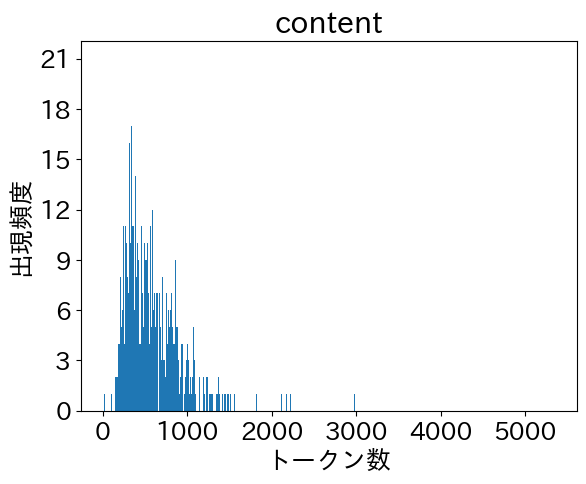

100%|██████████| 5893/5893 [00:01<00:00, 5031.57it/s]


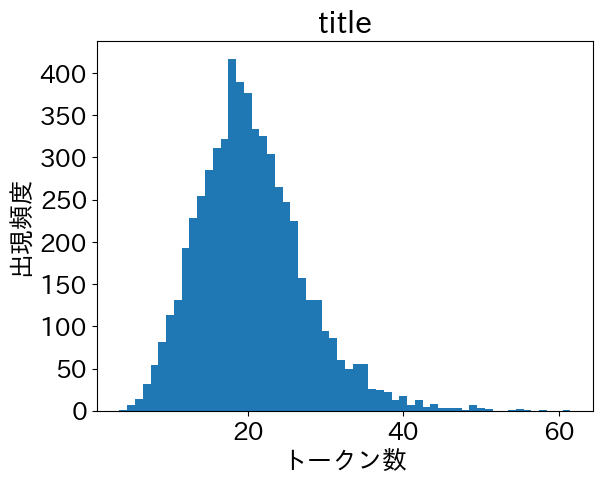

In [9]:
# トークナイザを読み込む
model_name = "retrieva-jp/t5-base-long"
tokenizer = AutoTokenizer.from_pretrained(model_name)
# 記事のトークン数の分布を可視化する
visualize_num_tokens_distribution(
    dataset["train"], tokenizer, "content"
)
# 見出しのトークン数の分布を可視化する
visualize_num_tokens_distribution(
    dataset["train"], tokenizer, "title"
)

## 7.3 評価指標

#### 準備

In [10]:
!pip install mecab-python3 rouge-score sacrebleu bert_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.4/591.4 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.9 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=ec5617f6c6434cebf4620bb9a9e56f1dec12d70521448426d00037af7dc7ab87
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


### 7.3.1 ROUGE (Recall-Oriented Understudy for Gisting Evaluation)

#### ROUGEを算出するための実装

In [ ]:
reference = "日本語T5モデルの公開"
prediction1 = "T5モデルの日本語版を公開"
prediction2 = "日本語Tをリリース"
prediction3 = "Japanese T5を発表"

In [12]:
import ipadic
import MeCab  # 高速で動作するオープンソースの日本語形態素解析エンジン

# IPAdicを用いたMeCabを使用して、単語分割を行う
tagger = MeCab.Tagger(f"-O wakati {ipadic.MECAB_ARGS}")
ref_wakati = tagger.parse(reference).strip()
pred_wakati1 = tagger.parse(prediction1).strip()
pred_wakati2 = tagger.parse(prediction2).strip()
pred_wakati3 = tagger.parse(prediction3).strip()

In [ ]:
print(f"参照文: {ref_wakati}")
print(f"生成文1: {pred_wakati1}")
print(f"生成文2: {pred_wakati2}")
print(f"生成文3: {pred_wakati3}")

参照文: 日本語 T 5 モデル の 公開
生成文1: T 5 モデル の 日本語 版 を 公開
生成文2: 日本語 T を リリース
生成文3: Japanese T 5 を 発表


In [14]:
from collections import defaultdict
import pandas as pd
from rouge_score import rouge_scorer, scoring

# pandasの小数点以下の桁数を3に設定する
pd.options.display.precision = 3

def convert_words_to_ids(
    predictions: list[str],
    references: list[str]
) -> tuple[list[str], list[str]]:
    """単語列をID列に変換"""
    # 単語にユニークなIDを割り当てるためのdefaultdictを作成する
    word2id = defaultdict(lambda: len(word2id))

    # 単語区切りの文字列をID文字列に変換する
    pred_ids = [
        " ".join([str(word2id[w]) for w in p.split()])
        for p in predictions
    ]
    ref_ids = [
        " ".join([str(word2id[w]) for w in p.split()])
        for p in references
    ]
    return pred_ids, ref_ids

def compute_rouge(
    predictions: list[str],
    references: list[str]
) -> dict[str, dict[str, float]]:
    """ROUGEを算出"""
    # RougeScorerを設定する
    rouge = rouge_scorer.RougeScorer(
        rouge_types=["rouge1", "rouge2", "rougeL"],
        use_stemmer=False
    )
    aggregator = scoring.BootstrapAggregator()  # 集計の初期化
    # 単語列をID列に変換する
    pred_ids, ref_ids = convert_words_to_ids(predictions, references)
    # ROUGEスコアを計算して結果を集約する
    for pred, ref in zip(pred_ids, ref_ids):
        aggregator.add_scores(rouge.score(ref, pred))
    scores = aggregator.aggregate()
    return {k: v.mid for k, v in scores.items()}  # midは平均値

In [15]:
# ROUGEを算出した結果を表示する
rouge_results = {
    "生成文1": compute_rouge([pred_wakati1], [ref_wakati]),
    "生成文2": compute_rouge([pred_wakati2], [ref_wakati]),
    "生成文3": compute_rouge([pred_wakati3], [ref_wakati]),
}
df_list = [
    pd.DataFrame.from_dict(rouge_results[k], orient="index")
    for k in rouge_results.keys()
]
display(pd.concat(df_list, keys=rouge_results.keys(), axis=1).T)

rouge1  rouge2  rougeL
生成文1 precision   0.750   0.429   0.625
     recall      1.000   0.600   0.833
     fmeasure    0.857   0.500   0.714
生成文2 precision   0.500   0.333   0.500
     recall      0.333   0.200   0.333
     fmeasure    0.400   0.250   0.400
生成文3 precision   0.400   0.250   0.400
     recall      0.333   0.200   0.333
     fmeasure    0.364   0.222   0.364

### 7.3.2 BLEU (BiLingual Evaluation Understudy)

#### BLEUを算出するための実装

In [16]:
from sacrebleu import corpus_bleu

def compute_bleu(
    predictions: list[str],
    references: list[list[str]]
) -> dict[str, int | float | list[float]]:
    """BLEUを算出"""
    result = corpus_bleu(predictions, references)
    return {
        "score": result.score,
        "counts": result.counts,
        "totals": result.totals,
        "precisions": [round(p,2) for p in result.precisions],
        "bp": result.bp,
        "sys_len": result.sys_len,
        "ref_len": result.ref_len
    }

In [17]:
# BLEUを算出した結果を表示する
bleu_results = {
    "生成文1": compute_bleu([pred_wakati1], [[ref_wakati]]),
    "生成文2": compute_bleu([pred_wakati2], [[ref_wakati]]),
    "生成文3": compute_bleu([pred_wakati3], [[ref_wakati]]),
}
df_list = [
    pd.DataFrame.from_dict(bleu_results[k], orient="index")[0]
    for k in bleu_results.keys()
]
display(pd.concat(df_list, keys=bleu_results.keys(), axis=1).T)

,score,counts,totals,precisions,bp,sys_len,ref_len
生成文1,38.26,"[6, 3, 2, 1]","[8, 7, 6, 5]","[75.0, 42.86, 33.33, 20.0]",1.0,8,6
生成文2,19.377,"[2, 1, 0, 0]","[4, 3, 2, 1]","[50.0, 33.33, 25.0, 25.0]",0.607,4,6
生成文3,17.492,"[2, 1, 0, 0]","[5, 4, 3, 2]","[40.0, 25.0, 16.67, 12.5]",0.819,5,6


### 7.3.3 BERTScore

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

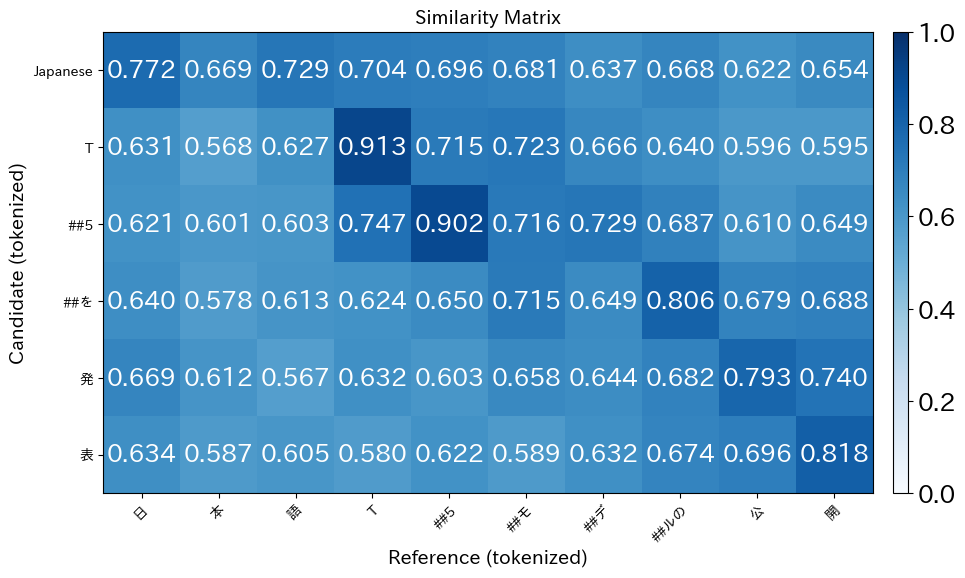

In [18]:
from bert_score import plot_example

# 生成文3と参照文の類似度行列を作成する
plot_example(prediction3, reference, lang="ja")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


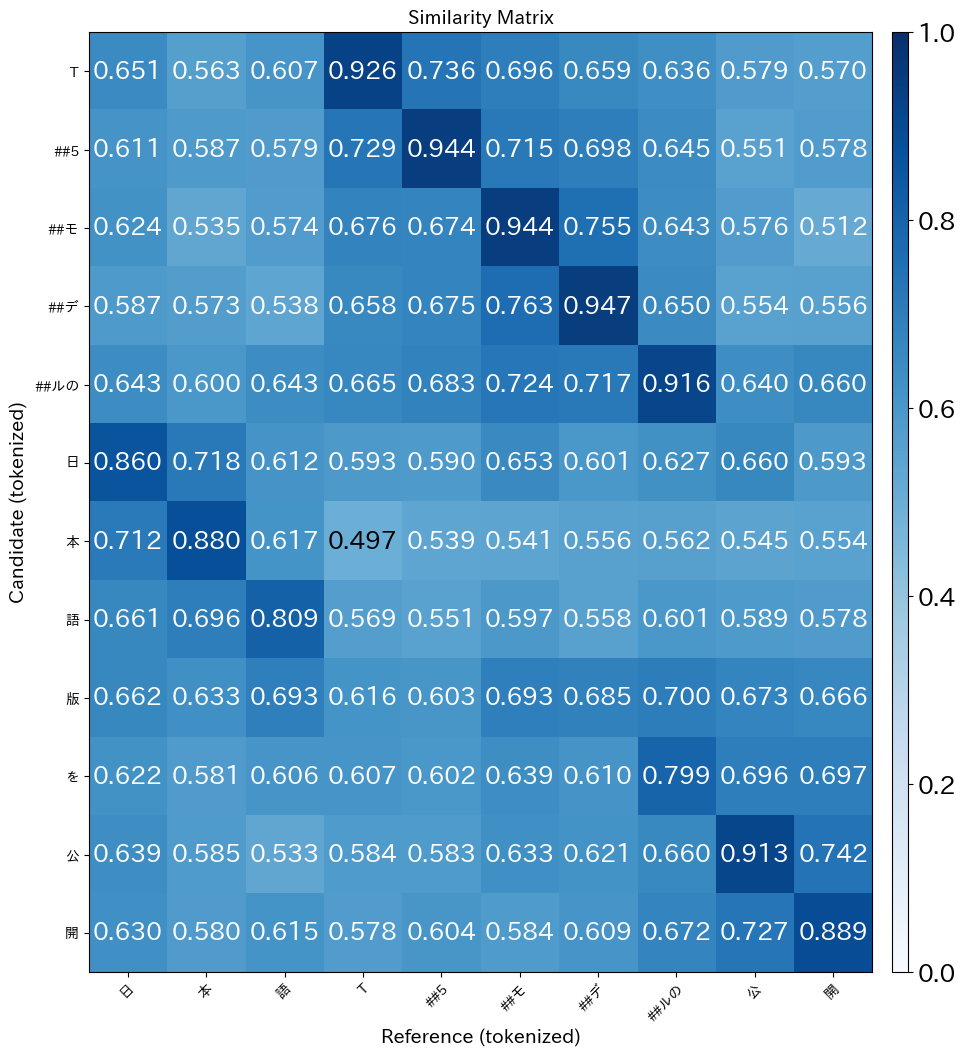

In [19]:
# 生成文1と参照文の類似度行列を作成する
plot_example(prediction1, reference, lang="ja")

#### BERTScoreを算出するための実装

In [ ]:
import bert_score

def compute_bertscore(
    predictions: list[str],
    references: list[str]
) -> dict[str, float]:
    """BERTScoreを計算する"""
    scorer = bert_score.BERTScorer(
        model_type=bert_score.utils.lang2model["ja"],
    )
    p, r, f = scorer.score(
        cands=predictions, 
        refs=references
    )
    return {
        "precision": sum(p.tolist()) / len(p),
        "recall": sum(r.tolist()) / len(r),
        "f1": sum(f.tolist()) / len(f)
    }

In [21]:
bertscore_results = {
    "生成文1": compute_bertscore([prediction1], [reference]),
    "生成文2": compute_bertscore([prediction2], [reference]),
    "生成文3": compute_bertscore([prediction3], [reference]),
}
df_list = [
    pd.DataFrame.from_dict(bertscore_results[k], orient="index")[0]
    for k in bertscore_results.keys()
]
display(pd.concat(df_list, keys=bertscore_results.keys(), axis=1).T)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


,precision,recall,f1
生成文1,0.877,0.903,0.890
生成文2,0.844,0.777,0.809
生成文3,0.834,0.785,0.809


## 7.4 見出し生成モデルの実装

### 7.4.1 T5のファインチューニング

#### データセットの前処理

In [22]:
from typing import Any
from transformers import BatchEncoding, PreTrainedTokenizer

def preprocess_data(
    data: dict[str, Any],
    tokenizer: PreTrainedTokenizer
) -> BatchEncoding:
    """データの前処理"""
    # 記事のトークナイゼーションを行う
    inputs = tokenizer(
        data["content"],
        max_length=512,
        truncation=True
    )
    # 見出しのトークナイゼーションを行う
    # 見出しはトークンIDのみ使用する
    inputs["labels"] = tokenizer(
        data["title"],
        max_length=128,
        truncation=True
    )["input_ids"]
    return inputs

In [23]:
# 訓練セットに対して前処理
train_dataset = dataset["train"].map(
    preprocess_data,
    fn_kwargs={"tokenizer": tokenizer},
    remove_columns=dataset["train"].column_names,
)
# 検証セットに対して前処理
validation_dataset = dataset["validation"].map(
    preprocess_data,
    fn_kwargs={"tokenizer": tokenizer},
    remove_columns=dataset["validation"].column_names,
)


Map:   0%|          | 0/5893 [00:00<?, ? examples/s]

Map:   0%|          | 0/736 [00:00<?, ? examples/s]

In [ ]:
print(dataset["train"])
print("----------------------")
print(train_dataset)

Dataset({
    features: ['url', 'date', 'title', 'content', 'category'],
    num_rows: 5893
})
----------------------
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 5893
})


#### モデルのファインチューニング

In [25]:
from transformers import AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq

# モデルを読み込む
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
# collate関数にDataCollatorForSeq2Seqを用いる
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/791 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [26]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments
from transformers.trainer_utils import set_seed

# 乱数シードを42に固定する
set_seed(42)

# Trainerに渡す引数を初期化する
training_args = Seq2SeqTrainingArguments(
    output_dir="output_t5_summarization", # 結果の保存フォルダ
    per_device_train_batch_size=8, # 訓練時のバッチサイズ
    per_device_eval_batch_size=8, # 評価時のバッチサイズ
    learning_rate=1e-4, # 学習率
    lr_scheduler_type="linear", # 学習率スケジューラ
    warmup_ratio=0.1, # 学習率のウォームアップ
    num_train_epochs=5, # 訓練エポック数
    evaluation_strategy="epoch", # 評価タイミング
    save_strategy="epoch", # チェックポイントの保存タイミング
    logging_strategy="epoch", # ロギングのタイミング
    load_best_model_at_end=True, # 訓練後に検証セットで最良のモデルをロード
    report_to="none",  # 外部ツールへのログを無効化
)

# Trainerを初期化する
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    tokenizer=tokenizer,
)

# 訓練する
trainer.train()

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
from google.colab import drive

# Google ドライブをマウントする
drive.mount("drive")

# 保存されたモデルをGoogleドライブのフォルダにコピーする
!mkdir -p drive/MyDrive/llm-book
!cp -r output_t5_summarization drive/MyDrive/llm-book

In [27]:
# すでにファインチューニングされたモデルを読み込む

# モデルを読み込む
model_name = "llm-book/t5-base-long-livedoor-news-corpus"
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to("cuda:0")
# パラメータをメモリ上に隣接した形で配置
# これを実行しない場合、モデルの保存でエラーになることがある
for param in model.parameters():
    param.data = param.data.contiguous()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

### 7.4.2 見出しの生成とモデルの評価

#### 見出しの生成

In [28]:
from torch.utils.data import DataLoader
from transformers import PreTrainedModel

def convert_list_dict_to_dict_list(
    list_dict: dict[str, list],
) -> list[dict[str, list]]:
    """ミニバッチのデータを事例単位のlistに変換"""
    dict_list = []
    # dictのキーのlistを作成する
    keys = list(list_dict.keys())
    for idx in range(len(list_dict[keys[0]])):  # 各事例で処理する
        # dictの各キーからデータを取り出してlistに追加する
        dict_list.append({
            key: list_dict[key][idx] 
            for key in keys
        })
    return dict_list

def run_generation(
    dataloader: DataLoader,
    model: PreTrainedModel
) -> list[dict[str, Any]]:
    """見出しを生成"""
    generations = []
    for batch in tqdm(dataloader):  # 各ミニバッチを処理する
        batch = {k: v.to(model.device) for k, v in batch.items() if k != "labels"}
        # 見出しのトークンのIDを生成する
        batch["generated_title_ids"] = model.generate(**batch)
        batch = {k: v.cpu().tolist() for k, v in batch.items()}
        # ミニバッチのデータを事例単位のlistに変換する
        generations += convert_list_dict_to_dict_list(batch)
    return generations

In [31]:
# テストセットに対して前処理を行う
test_dataset = dataset["test"].map(
    preprocess_data,
    fn_kwargs={"tokenizer": tokenizer},
    remove_columns=dataset["test"].column_names,
)
test_dataset = test_dataset.remove_columns(["labels"])
# ミニバッチの作成にDataLoaderを用いる
test_dataloader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=data_collator
)
# 見出しを生成する
generations = run_generation(test_dataloader, model)

  0%|          | 0/93 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
100%|██████████| 93/93 [01:12<00:00,  1.28it/s]


In [32]:
# 生成した見出しのトークンのIDのlistをトークンのlistに変換する
tokens = tokenizer.convert_ids_to_tokens(
    generations[0]["generated_title_ids"]
)
print(tokens)

['<pad>', '▁', '今日は', 'そういう', '日', 'だった', 'のか', '!', 'Google', 'ロゴ', 'が', '変わって', 'いる', '理由', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


In [33]:
def postprocess_title(
    generations: list[dict[str, Any]],
    dataset: list[dict[str, Any]],
    tokenizer: PreTrainedTokenizer,
) -> list[dict[str, str]]:
    """見出しの後処理"""
    results = []
    # 各事例を処理する
    for generation, data in zip(generations, dataset):
        # IDのlistをテキストに変換する
        data["generated_title"] = tokenizer.decode(
            generation["generated_title_ids"],
            skip_special_tokens=True,
        )
        results.append(data)
    return results

In [34]:
# 見出しテキストを生成する
results = postprocess_title(generations, dataset["test"], tokenizer)
print(results[0]["generated_title"])

今日はそういう日だったのか!Googleロゴが変わっている理由


#### モデルの評価

In [38]:
# ROUGEを算出して表示
generated_titles = [
    tagger.parse(r["generated_title"]).strip()
    for r in results
]
ref_titles = [
    tagger.parse(r["title"]).strip() 
    for r in results
]
rouge_results = compute_rouge(generated_titles, ref_titles)
display(pd.DataFrame.from_dict(rouge_results, orient="index"))

,precision,recall,fmeasure
rouge1,0.417,0.319,0.352
rouge2,0.215,0.157,0.176
rougeL,0.364,0.277,0.306


In [42]:
# BLEUを算出して表示する
generated_titles = [
    tagger.parse(r["generated_title"]).strip()
    for r in results
]
ref_titles = [[
    tagger.parse(r["title"]).strip() 
    for r in results
]]
bleu_results = compute_bleu(generated_titles, ref_titles)
display(pd.DataFrame([bleu_results]).rename(index={0: "BLEU"}).T)

,BLEU
score,13.523
counts,"[4439, 2151, 1292, 804]"
totals,"[10611, 9873, 9135, 8397]"
precisions,"[41.83, 21.79, 14.14, 9.57]"
bp,0.721
sys_len,10611
ref_len,14075


In [40]:
# BERTScoreを算出して表示する
generated_titles = [
    r["generated_title"].strip()
    for r in results
]
ref_titles = [
    r["title"].strip()
    for r in results
]
bertscore_results = compute_bertscore(generated_titles, ref_titles)
display(
    pd.DataFrame([bertscore_results]).rename(index={0: "BERTScore"})
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


,precision,recall,f1
BERTScore,0.757,0.726,0.741


In [41]:
# DataFrameのセル内の最大出力文字数を指定する
pd.options.display.max_colwidth = 500
# 記事、見出し、生成した見出しを表示する
display(
    pd.DataFrame(results)[:3][["content", "title", "generated_title"]]
)

,content,title,generated_title
0,「今日はそういう日だったのか！Googleロゴが変わっている理由」で紹介したように、Googleはたまにトップページのロゴを変える。今、Googleにアクセスすると、トップページのGoogleロゴが変わっているのに気づくだろう。 Googleロゴは、折り紙に見える。クリックすると、「吉澤章」という言葉が検索される。今日（3月14日）は、折り紙作家 吉澤章の誕生日だからだ。 吉澤章は、栃木県出身の折り紙作家だ。日本の創作折り紙の第一人者であるとともに、折り紙の世界的な普及に尽力したことで知られる。 興味を持った人は、インターネットで検索してみては如何だろうか。 ■Google ■Googleに関連した記事をもっと見る ・今日はそういう日だったのか！Googleロゴが変わっている理由 ・女子のすこやかな成長を祈る日！Googleロゴがひな祭りのひな壇に ・今日はそういう日だったのか！Googleロゴが歌うカエルである理由 周波数の単位に関係あり！Googleロゴが波のアニメの理由 できるポケット Google スマートに使いこなす基本＆活用ワザ 180 ［グーグル...,なるほど、そういうことか！Googleロゴが折り紙である理由,今日はそういう日だったのか!Googleロゴが変わっている理由
1,ビデオサロン12月号の記事連動の動画です。今回のテーマは「音量の合わせ方」です。詳しくは2011年12月号本誌をご覧ください。 関連記事 【ビデオマイスター】養成講座の内田氏がビデオ編集講座 ■ビデオSALON イベント・製品レポート 最新記事 ・11月号付録 キヤノン iVIS HF G10 Perfect Book 丸かじりダダウンロード ・【Special Report】ミドルレンジのビデオ制作者の有志が集まって結成したHD Usersが選んだATEM 1M/E Switcher ・第9回上映 中平悠里 監督作品『猫と少女の物語』 ・連載●After Effects 天国への階段第9回 ◆ビデオSALON2011年12月号 http://www.genkosha.co.jp/vs/backnumber/866.html ■関連記事 ・ソニーNXCAMのファームアップ情報【ビデオSALONI】 ・今度の貞子はネットを使って呪いを拡散？ 「リング」シリーズ最新作の構想が明らかに【話題】 ・土屋アンナが「今日はかわいく」紹介！ パナソニックが少数世帯向けのプチ家電を...,【記事連動】音の編集講座「音量の合わせ方」【ビデオSALON】,音量の合わせ方【ビデオSALON】
2,みずみずしい理想の肌に欠かせないのが”しっとり感”。しかし、冬が近づいてくると、乾燥によるカサカサ肌に悩む方も多いのではないでしょうか。乾燥に負けない理想のうるおい肌になるためには、自分にあった化粧品を惜しみなく使うことが大切です。 今、ちふれでは”自分にあった化粧品を、たっぷり使ってもらいたい”という想いのもと「なりたいきれい、好きなだけ。」キャンペーンを行なっています。女優の臼田あさみさんとモデルの雅姫さんをダブルで起用し、CMやキャンペーンサイトを展開。キャンペーンサイトでは、ちふれの人気アイテムが詰まった「なりたいきれい実感セット」が合計200名様に当たるプレゼントも12月27日まで実施中です。 この臼田あさみさんが出演するCMでもおなじみの「モイスチャー パウダー ファンデーション」は、3種の「しっとりやわらかパウダー」や、水分をつつみ込むダブルのうるおいオイルを配合。メイク中でも乾燥に負けず、長時間しっとりとしたお肌を保てます。スルスル広がり、溶け込むようにぴたっと密着するので、仕上がりも重くなりません。 さらにうるおい感を持続させるためには、下地として「メー...,【終了しました】しっとりなめらかな美肌を作る「ちふれ ベースメイクセット」を3名様にプレゼント,乾燥知らずのうるおい美肌を手に入れる「ちふれ ベースメイクセット」


## 7.5 多様な生成方法による見出し生成

In [64]:
content = dataset["test"][400]["content"]
title = dataset["test"][400]["title"]
print(f"記事: {content}")
print(f"見出し: {title}")

記事: 23日放送されたTBS「ひるおび！」に、北朝鮮・金正日総書記の専属料理人を務めていた藤本健二氏が出演し、7月に北朝鮮を訪問した際のエピソードを語った。  藤本氏が訪朝のために成田から経由地の北京に向かったのは7月20日。22日には平壌に到着し、金正恩第1書記と11年ぶりに再会した。その際、藤本氏は「裏切り者が帰って来ました」と泣きついたところ、金氏は「いいよ、いいよ」「裏切り行為はもう忘れた」と答えたという。その様子は撮影されており、8枚の写真が公開されたが、写真の中の藤本氏は普段の変装姿ではなく素顔であった。  今回の訪朝は金正恩氏からの招待であり、その旨を伝えるメッセンジャーなる人物は6月16日、コンビニから帰宅中の藤本氏に接触したという。  番組によればその際、メッセンジャーは「家族が会いたがっていますよ。そしてもう一人とても会いたがっている方がいらっしゃいます」と伝えるとともに、藤本氏が北朝鮮に残してきた妻子の写真と手紙を渡され、さらには「身の安全を徹底的に担保する」という北朝鮮当局よりの書類も見せられたという。  7月18日、再び藤本氏に接触してきたメッセンジャーは、藤本氏が日本への買い付けを理由に出国し、そのまま脱北した2001年の際、「帰ってきます」と当時の金正恩氏にした約束を果たそうではないかという金氏本人からメッセージを伝え、その2日後、藤本氏は北京へ向かったのである。  番組内では、今回の訪朝について「小泉元総理の日朝首脳会談からのちょうど10年という節目に何らかの意図」（高英起：デイリーNK）、「29日から日朝協議を前にし、金正恩氏と直接つながるパイプとしての藤本氏の存在を見せつける」（岩田宗一：TBS報道局解説委員）、「日朝関係改善の地ならし。北朝鮮としては藤本氏訪朝というものをなんとか成功させて日朝国交正常化まで突き進めたい」（鈴木琢磨：毎日新聞編集委員）などの分析が述べられた。  【関連記事】 ・料理人と北朝鮮とTBSの関係 ・金正恩と奇跡の再会。金正日の料理人、藤本健二「ひるおび！」連続出演中 ・元専属料理人の身辺調査　北工作員、忠誠判断に利用
見出し: 北朝鮮が元専属料理人に接触、“身の安全を徹底的に担保する”と訪朝打診


In [65]:
from functools import partial
from transformers import pipeline

set_seed(42)

# モデルを固定したpipelineを作成する
fixed_model_pipeline = partial(
    pipeline,
    "summarization",
    model=model,
    tokenizer=tokenizer,
    device="cuda:0",
)

#### 貪欲法

In [66]:
print(fixed_model_pipeline()(content)[0]["summary_text"])

金正恩氏に「裏切り者が帰って来ました」と泣きついた藤本健二


In [67]:
summarization_pipeline = fixed_model_pipeline(no_repeat_ngram_size=1)
print(summarization_pipeline(content)[0]["summary_text"])

金正恩氏に「裏切り者が帰って来ました」と泣きついた藤本健二


#### ビームサーチ

In [68]:
summarization_pipeline = fixed_model_pipeline(num_beams=5)
print(summarization_pipeline(content)[0]["summary_text"])

金正恩総書記の専属料理人、藤本健二氏が北朝鮮訪問


In [69]:
summarization_pipeline = fixed_model_pipeline(
    num_beams=5, num_return_sequences=5
)
for summary in summarization_pipeline(content):
    print(summary["summary_text"])

金正恩総書記の専属料理人、藤本健二氏が北朝鮮訪問
金正恩総書記の専属料理人、藤本健二氏が北朝鮮に訪問
金正恩総書記の専属料理人、藤本健二氏が北朝鮮訪問のエピソード
金正恩総書記の専属料理人、藤本健二氏が北朝鮮へ訪問
金正恩総書記の専属料理人、藤本健二氏が北朝鮮訪問の理由


### 7.5.2 サンプリングを用いたテキスト生成

In [70]:
summarization_pipeline = fixed_model_pipeline(do_sample=True, top_k=0)
print(summarization_pipeline(content)[0]["summary_text"])

まさかのまさかの訪朝、日本人男性は素顔!?


In [76]:
summarization_pipeline = fixed_model_pipeline(
    do_sample=True, top_k=0, temperature=0.1
)
print(summarization_pipeline(content)[0]["summary_text"])

金正恩氏に「裏切り者が帰って来ました」と泣きついた藤本健二


#### top-kサンプリング

In [79]:
summarization_pipeline = fixed_model_pipeline(
    do_sample=True, top_k=5, temperature=1.0
)
print(summarization_pipeline(content)[0]["summary_text"])

/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


金正恩氏と11年ぶりに再会、藤本健二氏が北朝鮮で「裏切り者が


#### top-pサンプリング

In [82]:
summarization_pipeline = fixed_model_pipeline(
    do_sample=True, top_k=3, top_p=0.8, temperature=1.3
)
print(summarization_pipeline(content)[0]["summary_text"])

北朝鮮・金正恩氏専属料理人、藤本健二氏が訪朝


### 7.5.3 長さを調整したテキスト生成

In [83]:
summarization_pipeline = fixed_model_pipeline(
    num_beams=3,
    num_return_sequences=3,
    min_new_tokens=5,
    max_new_tokens=5,
)
for summary in summarization_pipeline(content):
    print(summary["summary_text"])

金正恩氏
北朝鮮・金正
金正恩氏の


In [85]:
summarization_pipeline = fixed_model_pipeline(
    num_beams=3,
    num_return_sequences=3,
    min_new_tokens=35,
    max_new_tokens=35,
)
for summary in summarization_pipeline(content):
    print(summary["summary_text"])

北朝鮮・金正恩氏の専属料理人、藤本健二氏が訪朝した際のエピソードとは? 【話題】「ひるおび!」で藤本健二
北朝鮮・金正恩氏の専属料理人、藤本健二氏が訪朝した際のエピソードとは? 【話題】TBS「ひるおび!」に藤本健
北朝鮮・金正恩氏の専属料理人、藤本健二氏が訪朝した際のエピソードとは? 【話題】TBS「ひるおび!」で藤本健


In [86]:
summarization_pipeline = fixed_model_pipeline(
    num_beams=3,
    num_return_sequences=3,
    min_new_tokens=35,
    max_new_tokens=35,
    do_sample=True,
    temperature=1.3,
    no_repeat_ngram_size=3,
)
for summary in summarization_pipeline(content):
    print(summary["summary_text"])

北朝鮮・金正恩氏の専属料理人・藤本健二氏が訪朝した時の様子は? 「ひるおび!」で藤本氏に接触した
北朝鮮・金正恩氏の専属料理人・藤本健二氏が訪朝した時の様子は? 「ひるおび!」で藤本氏を直撃
北朝鮮・金正恩氏の専属料理人・藤本健二氏が訪朝した時の様子は? 「ひるおび!」で藤本氏に接触する
